# IT-мероприятия в России: конкурентный анализ и форматы для VK

Кто и как собирает IT-специалистов на конференции, митапы и подкасты — и что из этого стоит взять VK.

**Что внутри ноутбука**

1. Данные: 15 событий и серий, 6 критериев оценки, опрос 30 IT-специалистов, 8 идей для VK.
2. Взвешенный рейтинг конкурентов.
3. Проверка устойчивости рейтинга: 10 000 случайных наборов весов.
4. Карта рынка: PCA по оценкам.
5. Опрос: мотивы, форматы, каналы, связь региона и формата участия.
6. Приоритизация идей по ICE.
7. Выводы.

**Источники:** сайты организаторов (HighLoad++, JUG Ru, DUMP, CodeFest, AvitoTech, VK, Yandex Cloud), Хабр, vc.ru, kod.ru, Skillbox Media, Inc. Russia, Gartner Top Strategic Technology Trends 2026, Stack Overflow Developer Survey 2025, Sostav, Selecty, Хабр Карьера. Полный список — в `README.md`.

*Сентябрь 2026*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({
    'figure.dpi': 110, 'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#9aa0aa', 'axes.labelcolor': '#333333',
    'xtick.color': '#555555', 'ytick.color': '#555555',
    'axes.titleweight': 'bold', 'axes.titlesize': 12,
})

# Палитра: серый — рынок, синий — AvitoTech (ориентир), оранжевый — VK
GREY, BLUE, ORANGE, INK = '#b8bcc6', '#2a78d6', '#eb6834', '#1a1a1a'
def color_of(i):
    return ORANGE if i == 'VK' else BLUE if i == 'AV' else GREY

## 1. Данные

In [2]:
competitors = pd.read_csv('data/competitors.csv')
scores      = pd.read_csv('data/scores.csv')
criteria    = pd.read_csv('data/criteria.csv')
ideas       = pd.read_csv('data/ideas.csv')
survey      = pd.read_csv('data/survey_responses.csv')

df = competitors[['id', 'short_name', 'segment', 'organizer', 'price']].merge(scores, on='id')
df[['short_name', 'segment', 'organizer', 'price']]

,short_name,segment,organizer,price
0,HighLoad++,Платные конференции,Онтико,Saint HighLoad++ 2025 — от 48 500 ₽; Golang Conf X — от 21 000 ₽
1,JUG Ru Group,Платные конференции,JUG Ru Group,Платно; точные цены в источниках не нашёл
2,True Tech Day,Мегасобытия корпораций,МТС / MWS,Бесплатно по регистрации
3,T-Sync Conf,Мегасобытия корпораций,Т-Банк,Бесплатно по регистрации
4,ИТ-Пикник,Мегасобытия корпораций,Т-Банк + CodeFest + «Мельница»,Один билет — двое взрослых и двое детей; половина выручки уходит в благотвор...
5,Yandex Scale,Мегасобытия корпораций,Yandex Cloud,"Бесплатно, регистрация, число мест ограничено"
6,AI Journey,Мегасобытия корпораций,Сбер,Нет данных
7,Митапы Яндекса,Митапы компаний,Яндекс,Бесплатно
8,Ozon Tech,Митапы компаний,Ozon Tech,Бесплатно
9,VK,Митапы компаний,VK / VK Tech / VK Cloud,Бесплатно; на офлайн — анкета или регистрация


Каждое событие оценено по шкале 1–5 по шести критериям. Веса отражают то, что важнее всего инженеру, который решает, куда потратить вечер или два дня.

In [3]:
criteria

,criterion,label,weight
0,depth,Глубина контента,0.25
1,interactive,Интерактив и вовлечение,0.20
2,networking,Нетворкинг,0.15
3,reach,Охват и онлайн,0.15
4,accessibility,"Доступность (цена, география, порог входа)",0.10
5,community,Жизнь сообщества между событиями,0.15


## 2. Взвешенный рейтинг

In [4]:
CRIT = criteria['criterion'].tolist()
W = criteria.set_index('criterion')['weight']
assert abs(W.sum() - 1) < 1e-9

df['total'] = df[CRIT].mul(W).sum(axis=1)
df['rank'] = df['total'].rank(ascending=False, method='min').astype(int)
rating = df.sort_values('total', ascending=False)[['rank', 'short_name', 'segment'] + CRIT + ['total']]
rating.style.format({'total': '{:.2f}'}).background_gradient(subset=CRIT, cmap='Blues', vmin=1, vmax=5)

,rank,short_name,segment,depth,interactive,networking,reach,accessibility,community,total
14,1,AvitoTech,Митапы компаний,4,4,4,3,5,5,4.10
12,2,DUMP,Платные конференции,4,4,5,2,3,3,3.60
3,2,T-Sync Conf,Мегасобытия корпораций,4,5,4,2,4,2,3.60
13,2,CodeFest,Платные конференции,4,4,4,3,3,3,3.60
1,5,JUG Ru Group,Платные конференции,5,3,4,3,2,3,3.55
0,5,HighLoad++,Платные конференции,5,3,4,3,2,3,3.55
2,7,True Tech Day,Мегасобытия корпораций,3,4,3,5,5,2,3.55
10,7,Подлодка,Подкасты и онлайн-сезоны,4,4,2,3,4,4,3.55
7,9,Митапы Яндекса,Митапы компаний,4,3,3,3,5,3,3.45
8,10,Ozon Tech,Митапы компаний,3,3,3,3,5,4,3.35


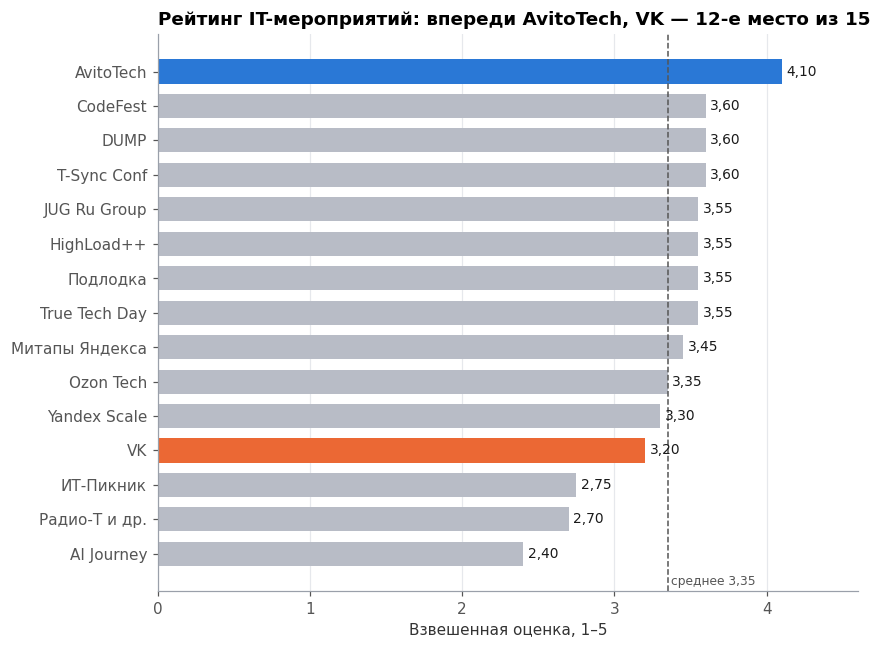

In [5]:
r = df.sort_values('total')
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(r['short_name'], r['total'], color=[color_of(i) for i in r['id']], height=0.7)
for b, v in zip(bars, r['total']):
    ax.text(v + 0.03, b.get_y() + b.get_height() / 2, f'{v:.2f}'.replace('.', ','), va='center', fontsize=9, color=INK)
ax.axvline(df['total'].mean(), color='#555555', lw=1, ls='--')
ax.text(df['total'].mean() + 0.02, -0.9, f"среднее {df['total'].mean():.2f}".replace('.', ','), fontsize=8, color='#555555')
ax.set_xlim(0, 4.6); ax.set_xlabel('Взвешенная оценка, 1–5')
ax.set_title('Рейтинг IT-мероприятий: впереди AvitoTech, VK — 12-е место из 15', loc='left')
ax.grid(axis='x', color='#e6e8ec', lw=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

AvitoTech выигрывает не масштабом, а ритмом: нумерованные серии митапов по всем направлениям, дринкапы, Fuckup Night, собеседования в прямом эфире, свой подкаст. Мегасобытия МТС и Т-Банка сильны охватом и интерактивом, но между выпусками аудитория расходится.

In [6]:
market = df[CRIT].mean()
comp = pd.DataFrame({'Среднее по рынку': market, 'AvitoTech': df.set_index('id').loc['AV', CRIT],
                     'VK': df.set_index('id').loc['VK', CRIT]})
comp.index = criteria['label'].str.split(' \\(').str[0]
comp['VK − рынок'] = comp['VK'] - comp['Среднее по рынку']
comp.round(2)

,Среднее по рынку,AvitoTech,VK,VK − рынок
label,,,,
Глубина контента,3.60,4,4,0.40
Интерактив и вовлечение,3.47,4,3,-0.47
Нетворкинг,3.33,4,3,-0.33
Охват и онлайн,3.07,3,3,-0.07
Доступность,3.87,5,4,0.13
Жизнь сообщества между событиями,2.73,5,2,-0.73


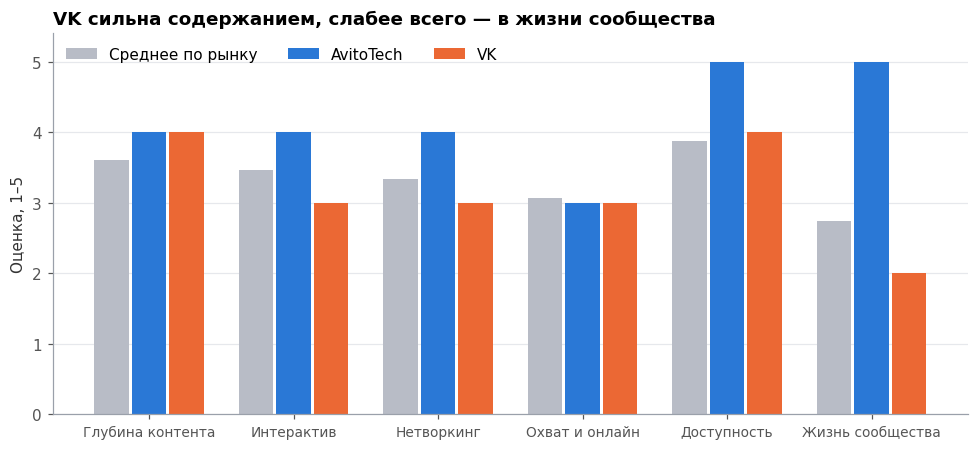

In [7]:
x = np.arange(len(CRIT)); w = 0.26
fig, ax = plt.subplots(figsize=(9, 4.2))
for k, (col, c) in enumerate([('Среднее по рынку', GREY), ('AvitoTech', BLUE), ('VK', ORANGE)]):
    ax.bar(x + (k - 1) * w, comp[col], w * 0.92, label=col, color=c)
ax.set_xticks(x, [s.replace(' между событиями', '').replace(' и вовлечение', '') for s in comp.index], fontsize=9)
ax.set_ylim(0, 5.4); ax.set_ylabel('Оценка, 1–5')
ax.set_title('VK сильна содержанием, слабее всего — в жизни сообщества', loc='left')
ax.legend(frameon=False, ncol=3, loc='upper left')
ax.grid(axis='y', color='#e6e8ec', lw=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 3. Насколько рейтинг зависит от весов

Веса критериев — экспертное решение. Проверим, не держится ли вывод только на них: сгенерируем 10 000 случайных наборов весов (распределение Дирихле вокруг базовых весов) и посмотрим, как часто каждое событие попадает в тройку лидеров и на каком месте оказывается VK.

In [8]:
rng = np.random.default_rng(42)
N = 10_000
alpha = W.values * 20                       # концентрация вокруг базовых весов
Ws = rng.dirichlet(alpha, size=N)           # N x 6
S = df[CRIT].values                         # 15 x 6
totals = S @ Ws.T                           # 15 x N
ranks = (-totals).argsort(axis=0).argsort(axis=0) + 1

sens = pd.DataFrame({
    'Событие': df['short_name'],
    'Медианное место': np.median(ranks, axis=1).astype(int),
    'Место 1, %': (ranks == 1).mean(axis=1) * 100,
    'Топ-3, %': (ranks <= 3).mean(axis=1) * 100,
}).sort_values('Медианное место')
sens.style.format({'Место 1, %': '{:.0f}', 'Топ-3, %': '{:.0f}'})

,Событие,Медианное место,"Место 1, %","Топ-3, %"
14,AvitoTech,1,92,100
1,JUG Ru Group,5,0,22
12,DUMP,5,1,32
3,T-Sync Conf,5,2,36
13,CodeFest,5,0,12
10,Подлодка,6,0,26
0,HighLoad++,6,2,27
2,True Tech Day,6,4,31
7,Митапы Яндекса,8,0,6
8,Ozon Tech,10,0,6


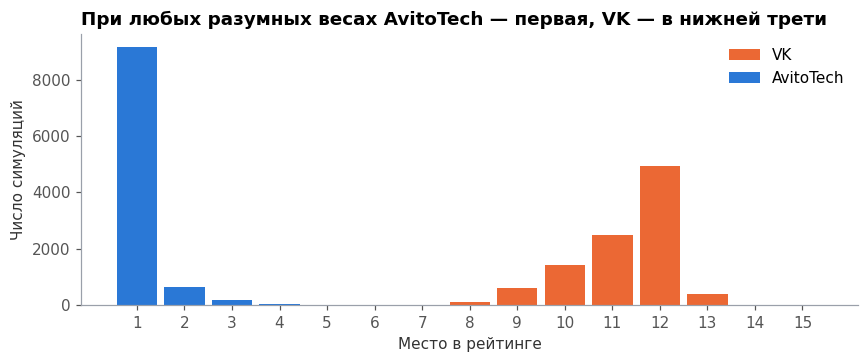

AvitoTech на 1-м месте в 92% симуляций; VK в топ-5 — в 0.0%.


In [9]:
vk_i = df.index[df['id'] == 'VK'][0]
av_i = df.index[df['id'] == 'AV'][0]
fig, ax = plt.subplots(figsize=(8, 3.4))
bins = np.arange(0.5, 16.5, 1)
ax.hist(ranks[vk_i], bins=bins, color=ORANGE, rwidth=0.85, label='VK')
ax.hist(ranks[av_i], bins=bins, color=BLUE, rwidth=0.85, label='AvitoTech')
ax.set_xticks(range(1, 16)); ax.set_xlabel('Место в рейтинге'); ax.set_ylabel('Число симуляций')
ax.set_title('При любых разумных весах AvitoTech — первая, VK — в нижней трети', loc='left')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(f"AvitoTech на 1-м месте в {(ranks[av_i] == 1).mean():.0%} симуляций; "
      f"VK в топ-5 — в {(ranks[vk_i] <= 5).mean():.1%}.")

## 4. Карта рынка

Сжимаем шесть критериев до двух главных компонент. Близкие точки — события с похожим профилем сильных и слабых сторон.

In [10]:
X = StandardScaler().fit_transform(df[CRIT])
pca = PCA(n_components=2).fit(X)
P = pca.transform(X)
load = pd.DataFrame(pca.components_.T, index=criteria['label'], columns=['PC1', 'PC2']).round(2)
print('Доля объяснённой дисперсии:', np.round(pca.explained_variance_ratio_, 2))
load

Доля объяснённой дисперсии: [0.38 0.23]


,PC1,PC2
label,,
Глубина контента,0.48,0.37
Интерактив и вовлечение,0.35,-0.00
Нетворкинг,0.54,-0.30
Охват и онлайн,-0.42,-0.02
"Доступность (цена, география, порог входа)",-0.39,0.41
Жизнь сообщества между событиями,0.18,0.78


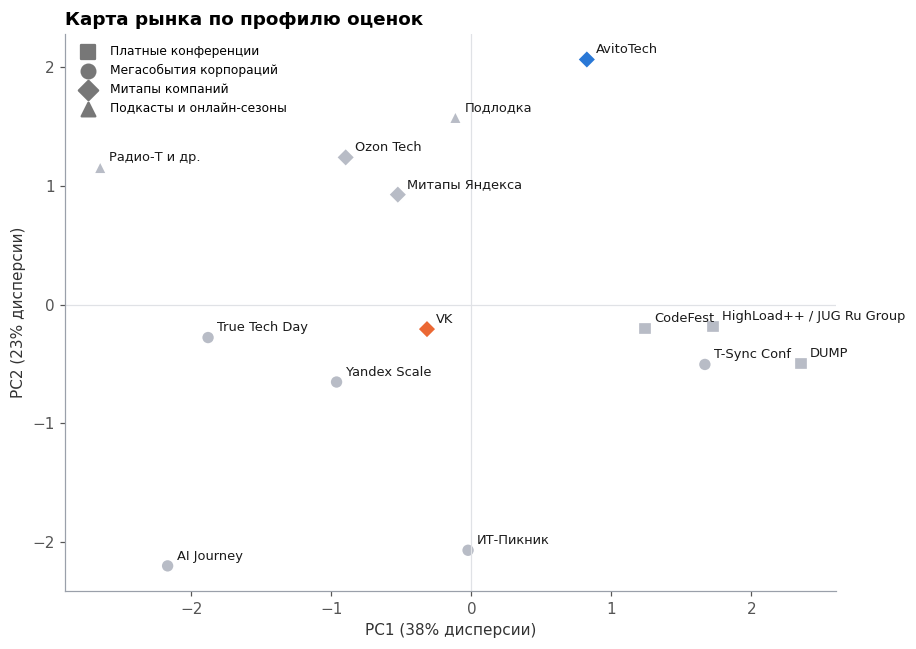

In [11]:
seg_marker = {'Платные конференции': 's', 'Мегасобытия корпораций': 'o', 'Митапы компаний': 'D', 'Подкасты и онлайн-сезоны': '^'}
fig, ax = plt.subplots(figsize=(8.5, 6))
for seg, m in seg_marker.items():
    mask = df['segment'] == seg
    ax.scatter(P[mask, 0], P[mask, 1], marker=m, s=80, c=[color_of(i) for i in df.loc[mask, 'id']],
               edgecolors='white', linewidths=1.5, label=seg)
# у HighLoad++ и JUG Ru одинаковые оценки — подписываем точку один раз
labels = {}
for (px, py), name in zip(P, df['short_name']):
    labels.setdefault((round(px, 3), round(py, 3)), []).append(name)
for (px, py), names in labels.items():
    ax.annotate(' / '.join(names), (px, py), xytext=(6, 4), textcoords='offset points', fontsize=8.5, color=INK)
ax.axhline(0, color='#e0e2e6', lw=0.8); ax.axvline(0, color='#e0e2e6', lw=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} дисперсии)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} дисперсии)')
ax.set_title('Карта рынка по профилю оценок', loc='left')
leg = ax.legend(frameon=False, fontsize=8, loc='best')
for h in leg.legend_handles: h.set_color('#777777')
plt.tight_layout(); plt.show()

Первая компонента разводит камерные события с глубиной и нетворкингом (HighLoad++, JUG Ru, DUMP) и массовые, где важнее охват и доступность (True Tech Day, AI Journey). Вторая компонента — это прежде всего жизнь сообщества между встречами: наверху AvitoTech, Ozon Tech и Подлодка, внизу мегасобытия, которые случаются раз в год. VK стоит рядом с митапами Яндекса и Ozon Tech, но ниже их по второй оси: содержание есть, сообщества не хватает.

## 5. Опрос IT-специалистов

Анкета из 15 вопросов, модельная выборка n = 30. Структура по ролям, опыту и городам и базовые установки откалиброваны по открытым исследованиям: Stack Overflow Developer Survey 2025, опрос Sostav 2026, Selecty 2025, данные Хабр Карьеры.

In [12]:
print(f'Респондентов: {len(survey)}')
pd.concat({
    'Регион': survey['region'].value_counts(),
    'Опыт': survey['exp'].value_counts(),
}).to_frame('человек')

Респондентов: 30


человек
Регион Москва                    12
       Другой город России       11
       Санкт-Петербург            5
       Другая страна              2
Опыт   Больше 6 лет              12
       3–6 лет                   11
       1–3 года                   5
       Меньше года                2

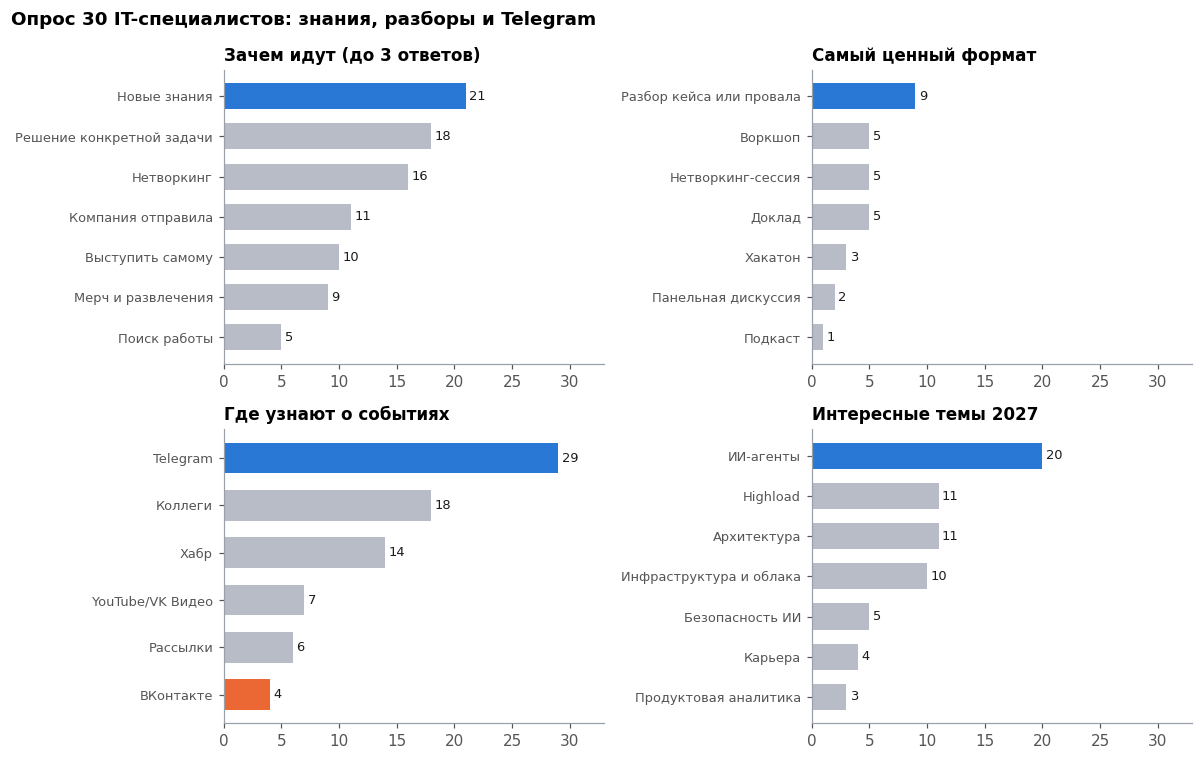

In [13]:
def multi(col):
    return survey[col].str.split('; ').explode().value_counts()

blocks = {
    'Зачем идут (до 3 ответов)': multi('reasons'),
    'Самый ценный формат': survey['top_format'].value_counts(),
    'Где узнают о событиях': multi('channels'),
    'Интересные темы 2027': multi('topics'),
}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (title, s) in zip(axes.ravel(), blocks.items()):
    s = s.sort_values()
    hl = [ORANGE if k in ('ВКонтакте',) else BLUE if v == s.max() else GREY for k, v in s.items()]
    ax.barh(s.index, s.values, color=hl, height=0.65)
    for i, v in enumerate(s.values):
        ax.text(v + 0.3, i, str(v), va='center', fontsize=8.5, color=INK)
    ax.set_title(title, loc='left', fontsize=11); ax.set_xlim(0, 33)
    ax.tick_params(axis='y', labelsize=8.5)
fig.suptitle('Опрос 30 IT-специалистов: знания, разборы и Telegram', x=0.01, ha='left', fontweight='bold')
plt.tight_layout(); plt.show()

Три вещи бросаются в глаза. Люди идут за знаниями и решением конкретных задач, а не за мерчем. Лучший формат — разбор реального кейса или провала. О событиях узнают из Telegram, ВКонтакте для этой аудитории почти не работает как канал анонсов.

### Регион и формат участия

In [14]:
survey['offline_pref'] = survey['format_pref'].str.contains('офлайн', case=False)
survey['moscow_spb'] = survey['region'].isin(['Москва', 'Санкт-Петербург'])
ct = pd.crosstab(survey['moscow_spb'].map({True: 'Москва и СПб', False: 'Другие города и страны'}),
                 survey['offline_pref'].map({True: 'Скорее офлайн', False: 'Онлайн или без разницы'}))
ct

offline_pref,Онлайн или без разницы,Скорее офлайн
moscow_spb,,
Другие города и страны,8,5
Москва и СПб,9,8


In [15]:
odds, p = stats.fisher_exact(ct.values)
print(f'Точный тест Фишера: OR = {odds:.2f}, p = {p:.3f}')

Точный тест Фишера: OR = 1.42, p = 0.721


Направление ожидаемое: жители Москвы и Петербурга чаще выбирают офлайн, регионы — онлайн. При n = 30 разница не достигает статистической значимости, поэтому для решения о формате региональной программы нужна волна опроса от 300 ответов. Ноутбук готов её посчитать: достаточно заменить `data/survey_responses.csv`.

In [16]:
pay = survey['pay'].value_counts().reindex(['0 ₽', 'До 5 000 ₽', '5 000–15 000 ₽', '15 000–30 000 ₽', 'Больше 30 000 ₽', 'Платит компания'])
attended = multi('attended').drop(['—', 'Другое'], errors='ignore')
pd.concat({'Готовность платить за 2 дня': pay, 'Где были за год': attended}).to_frame('человек')

человек
Готовность платить за 2 дня 0 ₽                    9
                            До 5 000 ₽             8
                            5 000–15 000 ₽         6
                            15 000–30 000 ₽        1
                            Больше 30 000 ₽        1
                            Платит компания        5
Где были за год             HighLoad++             8
                            AvitoTech              7
                            ИТ-Пикник              5
                            True Tech Day          5
                            JUG Ru                 4
                            CodeFest               4
                            T-Sync Conf            3
                            DUMP                   3
                            Митапы VK              3
                            Yandex Scale           3
                            Ozon Tech              2
                            AI Journey             2
                            Митапы Яндекса         1

## 6. Идеи для VK: приоритизация по ICE

In [17]:
ideas['ICE'] = ideas['impact'] * ideas['confidence'] * ideas['ease']
ideas.sort_values('ICE', ascending=False)[['idea', 'impact', 'confidence', 'ease', 'ICE', 'kpi']]

,idea,impact,confidence,ease,ICE,kpi
0,«Ночь постмортемов VK»: разборы реальных сбоев,5,4,4,80,Доля повторных участников ≥ 40%; досмотры записи; число вопросов на разбор
2,Живой подкаст «В проде»,4,4,5,80,Прослушивания и досмотры; подписчики шоу; переходы на анонсы событий
1,«Сезоны VK Tech»: неделя одной темы онлайн,5,4,3,60,Доля сдавших домашку; конверсия в отклики на вакансии; NPS
3,Единая витрина VK Tech Community,4,4,3,48,"Регистрации через витрину; доля участников, посетивших 2+ события за полгода"
5,Хакатон «Мультиагент за выходные»,4,3,3,36,"Число заявок; доля senior-команд; продукты, дошедшие до пилота"
6,Региональный тур и студенческий трек,3,4,3,36,Участники вне Москвы и СПб; отклики на стажировки
7,IT-зона на VK Fest,3,3,4,36,Посетители зоны; регистрации в витрине сообщества прямо на месте
4,«Положи стенд»: нагрузочный челлендж,4,3,2,24,Число команд; время зрителей у стенда; упоминания в соцсетях


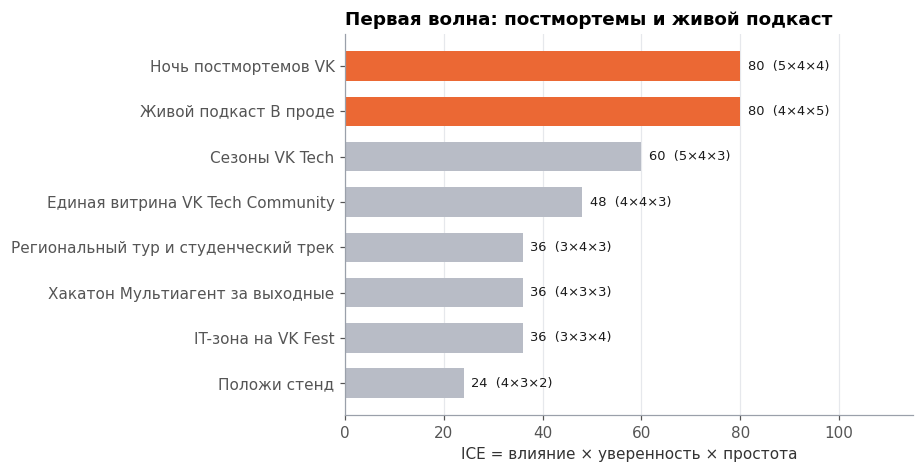

In [18]:
r = ideas.sort_values('ICE')
fig, ax = plt.subplots(figsize=(8.5, 4.4))
names = r['idea'].str.split(':').str[0].str.replace('«', '').str.replace('»', '')
bars = ax.barh(names, r['ICE'], color=[ORANGE if v >= 80 else GREY for v in r['ICE']], height=0.65)
for b, (_, row) in zip(bars, r.iterrows()):
    ax.text(row['ICE'] + 1.5, b.get_y() + b.get_height() / 2,
            f"{row['ICE']}  ({row['impact']}×{row['confidence']}×{row['ease']})", va='center', fontsize=8.5, color=INK)
ax.set_xlim(0, 115); ax.set_xlabel('ICE = влияние × уверенность × простота')
ax.set_title('Первая волна: постмортемы и живой подкаст', loc='left')
ax.grid(axis='x', color='#e6e8ec', lw=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 7. Выводы

1. **Мегаконференция VK не нужна.** Рынок шоу поделили МТС, Т-Банк и Яндекс. Ориентир для VK — AvitoTech: компания того же класса, которая выигрывает ритмом, доступностью и сообществом между встречами. Вывод устойчив к выбору весов: AvitoTech первая в 92% из 10 000 симуляций, VK ни разу не попадает в топ-5.
2. **Слабое место VK — удержание и узнаваемость, а не содержание.** По глубине VK выше среднего (4 против 3,6), по жизни сообщества — 2 против 2,7 в среднем и 5 у AvitoTech. В опросе митапы VK видели 3 человека из 30, события AvitoTech — 7.
3. **Аудитория хочет реального опыта.** Разбор кейса или провала — самый ценный формат; анонсы должны идти через Telegram.
4. **Первая волна — два дешёвых формата:** «Ночь постмортемов VK» (технические разборы highload-инцидентов) и живой подкаст «В проде» с дистрибуцией через VK Видео и VK Музыку. Затем — «Сезоны VK Tech» и единая витрина событий.

**Следующий шаг:** волна опроса от 300 ответов в сообществе VK Team и Telegram-каналах команд — и перезапуск этого ноутбука на новых данных.